In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , StackingClassifier , AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score , classification_report , confusion_matrix
from sklearn import set_config

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout , Dense , Input
from tensorflow.keras import regularizers
from scikeras.wrappers import KerasClassifier

I0000 00:00:1782328209.301366 1409473 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782328209.344196 1409473 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782328210.845359 1409473 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df_train = pd.read_csv('/home/kyburg/kaggle/input/predicting_stellar_class/train.csv')
df_test = pd.read_csv('/home/kyburg/kaggle/input/predicting_stellar_class/test.csv')

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 62.9 MB


In [5]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  str    
 10  galaxy_population  247435 non-null  str    
dtypes: float64(8), int64(1), str(2)
memory usage: 23.8 MB


In [6]:
df_train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [7]:
df_train['spectral_type'].unique()

<ArrowStringArray>
['M', 'O/B', 'G/K', 'A/F']
Length: 4, dtype: str

In [8]:
df_train['galaxy_population'].unique()

<ArrowStringArray>
['Red_Sequence', 'Blue_Cloud']
Length: 2, dtype: str

In [4]:
def eda(df, subplots_rows, subplots_cols, plot_conf):
    df = df.copy()
    if len(plot_conf) > subplots_rows * subplots_cols:
        print(f'More plot configurations ({len(plot_conf)}) were given than subplots')
        print(f'Using only the first {subplots_rows * subplots_cols} configurations')
        plot_conf = plot_conf[:subplots_rows * subplots_cols]
    fig, axes = plt.subplots(subplots_rows, subplots_cols, figsize=(20, 20))
    for i in range(subplots_rows):
        for j in range(subplots_cols):
            try:
                current_conf = plot_conf[i * subplots_cols + j]
            except:
                continue
            if current_conf['Plot'] == 'pivot_heatmap':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'sum'
                data = df.pivot_table(
                    values = current_conf['values'],
                    index = current_conf['index'],
                    columns = current_conf['columns'],
                    aggfunc = aggfunc
                )
                annot = current_conf['annot'] if 'annot' in current_conf.keys() else True
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'coolwarm'
                sns.heatmap(data, annot=annot, cmap=colormap, ax=axes[i,j])
            elif current_conf['Plot'] == 'boxplot':
                data = [df.dropna()[df[current_conf['columns']] == m][current_conf['values']].values 
                        for m in pd.unique(df[current_conf['columns']].dropna())]
                labels = pd.unique(df[current_conf['columns']].dropna())
                axes[i, j].boxplot(data, tick_labels=labels)
            elif current_conf['Plot'] == 'hist':
                nbins = current_conf['bins'] if 'bins' in current_conf.keys() else 10
                df[current_conf['columns']].hist(bins=nbins, ax=axes[i,j])
            elif current_conf['Plot'] == 'barh':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'mean'
                data = df.groupby(current_conf['columns'])[current_conf['values']].agg(aggfunc).sort_values(ascending=False)
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'steelblue'
                axes[i, j].barh(range(len(data)), data.values, color=colormap)
            elif current_conf['Plot'] == 'corr':
                data = df[current_conf['columns']].corr()
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'coolwarm'
                sns.heatmap(data, annot=True, cmap=colormap, ax=axes[i,j])
            elif current_conf['Plot'] == 'scatter':
                if 'values' in current_conf.keys():
                    sns.scatterplot(data=df, x=current_conf['index'], y=current_conf['columns'], hue=current_conf['values'], legend='full', ax=axes[i,j])
                else:
                    sns.scatterplot(data=df, x=current_conf['index'], y=current_conf['columns'], legend='full', ax=axes[i,j])
            elif current_conf['Plot'] == 'discrete_scatter':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'sum'
                data = df.groupby([current_conf['columns']] + [current_conf['index']], as_index=False)[current_conf['values']].agg(aggfunc)
                sns.scatterplot(data=data, x=current_conf['index'], y=current_conf['columns'], size=current_conf['values'], sizes=(50,500), legend='full', ax=axes[i,j])
            elif current_conf['Plot'] == 'bar':
                df.groupby(current_conf['columns']).size().unstack().plot.bar(ax=axes[i,j])
            elif current_conf['Plot'] == 'kde':
                for m in  pd.unique(df[current_conf['columns']].dropna()):
                    df[df[current_conf['columns']] == m][current_conf['values']].plot.kde(ax=axes[i,j], label=m)
                axes[i,j].legend()
            else:
                print(f"Unrecognized plot: '{current_conf['Plot']}'\n{'-' * 10} Skipping {'-' * 10}")
            if 'title' in current_conf.keys():
                axes[i, j].set_title(current_conf['title'], fontweight='bold')
            if 'set_ylabel' in current_conf.keys():
                axes[i, j].set_ylabel(current_conf['set_ylabel'], fontweight='bold')
            if 'set_xlabel' in current_conf.keys():
                axes[i, j].set_xlabel(current_conf['set_xlabel'], fontweight='bold')
            if 'set_yticks' in current_conf.keys() and current_conf['set_yticks']:
                axes[i, j].set_yticks(range(len(data)))
            if 'set_yticklabels' in current_conf.keys() and current_conf['set_yticklabels']:
                axes[i, j].set_yticklabels(data.index)
            if 'grid' in current_conf.keys():
                axes[i, j].grid(axis=current_conf['grid'][0], alpha=current_conf['grid'][1])

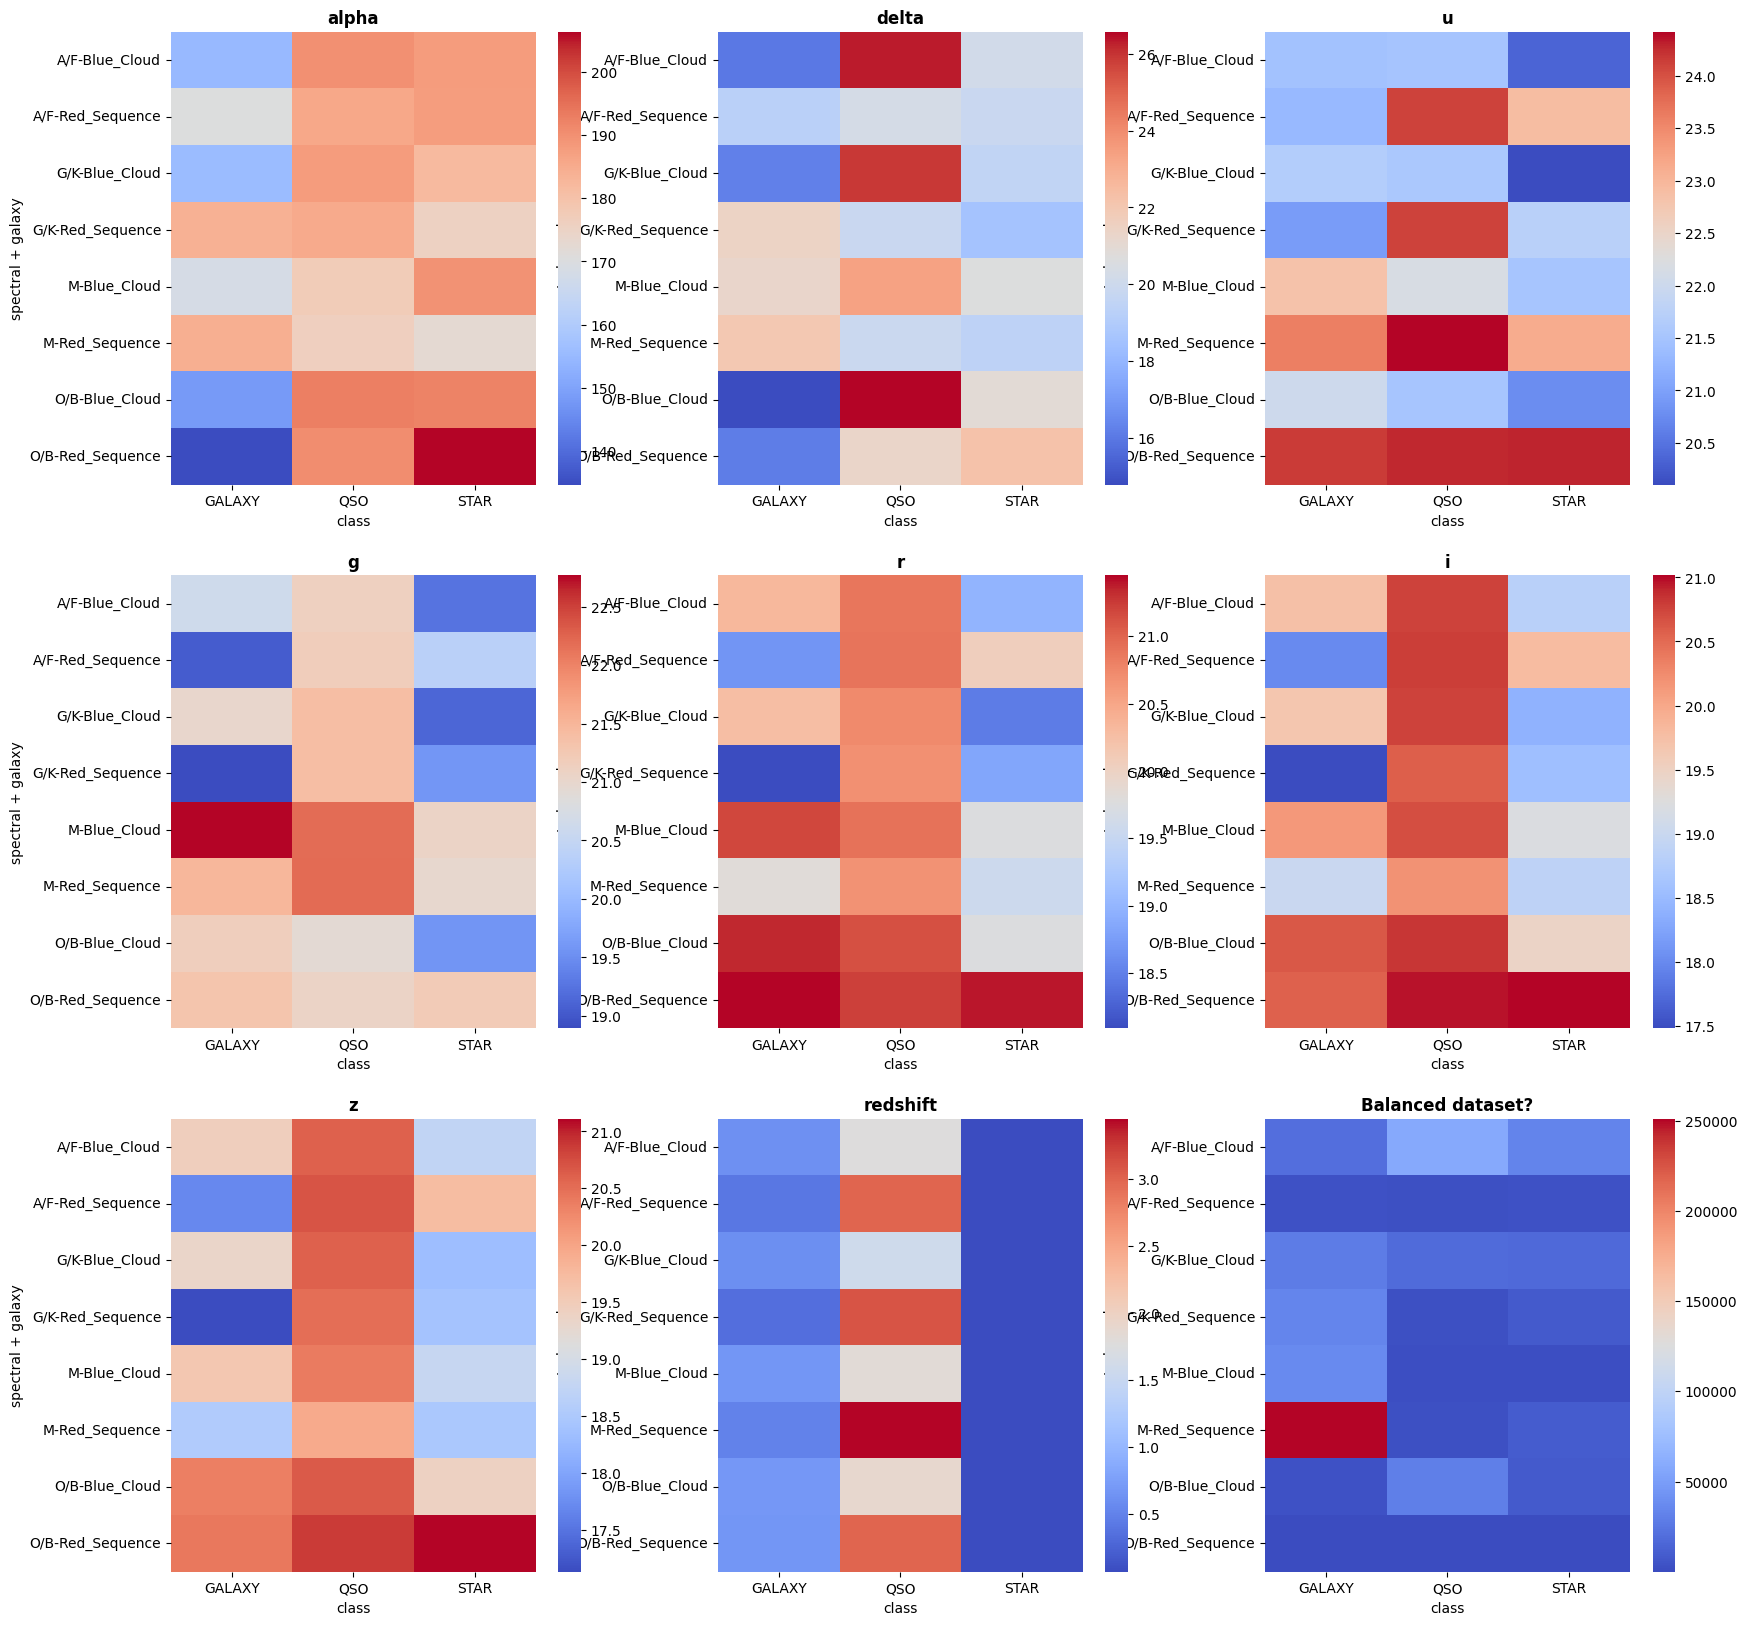

In [10]:
df_eda = df_train.copy()
df_eda['spectral + galaxy'] = df_eda['spectral_type'] + '-' + df_eda['galaxy_population']
eda(df_eda, 3, 3, [
    {'Plot' : 'pivot_heatmap' , 'values' : 'alpha' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'alpha'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'delta' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'delta'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'u' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'u'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'g' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'g'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'r' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'r'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'i' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'i'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'z' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'z'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'redshift' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'redshift'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'id' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'count', 'title' : 'Balanced dataset?'}
])

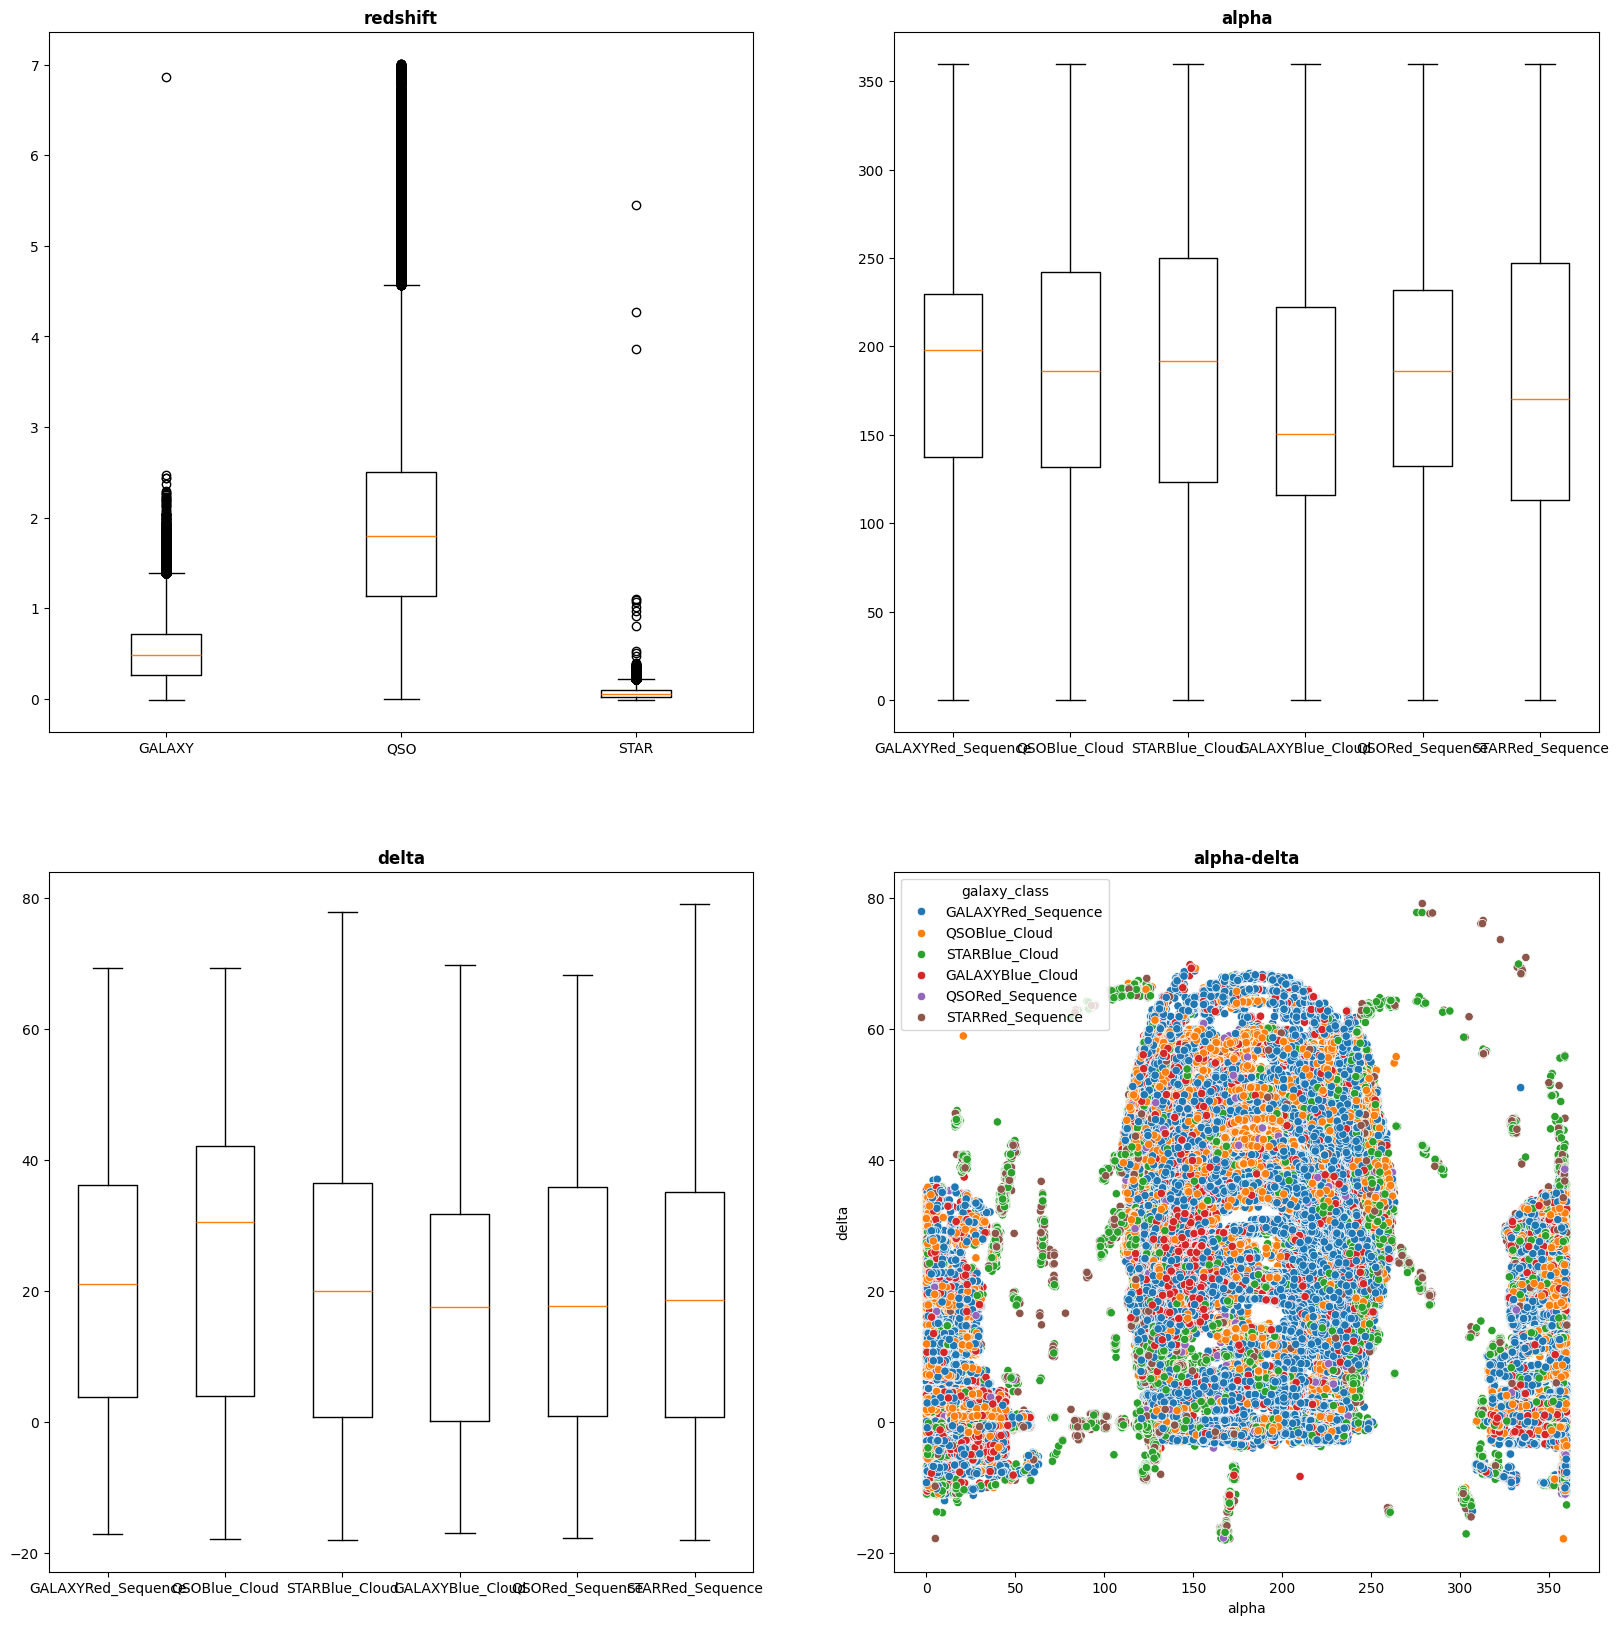

In [15]:
df_eda['galaxy_class'] = df_eda['class'] + df_eda['galaxy_population']
eda(df_eda, 2, 2, [
    {'Plot' : 'boxplot' , 'values' : 'redshift' , 'columns' : 'class', 'annot' : False, 'title' : 'redshift'},
    {'Plot' : 'boxplot' , 'values' : 'alpha','columns' : 'galaxy_class', 'annot' : False , 'title' : 'alpha'},
    {'Plot' : 'boxplot' , 'values' : 'delta','columns' : 'galaxy_class', 'annot' : False , 'title' : 'delta'},
    {'Plot' : 'scatter' , 'index' : 'alpha', 'columns' : 'delta', 'annot' : False, 'title' : 'alpha-delta', 'values' : 'galaxy_class'},
])

In [21]:
df_eda[df_eda['redshift'] <=0]

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,...,r_norm,i_norm,z_norm,u_log,g_log,r_log,i_log,z_log,spectral + galaxy,galaxy_class
19,19,157.752619,18.879351,19.489760,18.047867,17.546190,17.652735,16.891979,-0.007928,G/K,...,0.195766,0.196954,0.188467,2.969889,2.893027,2.864837,2.870891,2.826839,G/K-Blue_Cloud,STARBlue_Cloud
38,38,7.685625,24.111288,19.937545,18.815244,18.060795,18.328763,18.216197,-0.007431,G/K,...,0.193456,0.196327,0.195121,2.992605,2.934667,2.893744,2.908472,2.902311,G/K-Blue_Cloud,STARBlue_Cloud
54,54,200.939804,37.717396,18.341243,17.742723,17.620236,17.154225,17.084990,-0.002657,A/F,...,0.200359,0.195060,0.194273,2.909152,2.875975,2.869048,2.842245,2.838200,A/F-Blue_Cloud,GALAXYBlue_Cloud
76,76,238.187029,27.739347,21.017296,19.540641,19.611182,19.002819,19.345795,-0.002458,O/B,...,0.199062,0.192887,0.196369,3.045346,2.972496,2.976100,2.944587,2.962475,O/B-Blue_Cloud,STARBlue_Cloud
121,121,123.063256,20.638266,21.566960,20.131068,17.784286,17.257919,16.782161,-0.000920,M,...,0.190161,0.184532,0.179445,3.071162,3.002264,2.878315,2.848271,2.820317,M-Red_Sequence,STARRed_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577203,577203,134.087910,29.233930,21.953722,20.836522,21.126718,21.438156,21.192999,-0.009115,O/B,...,0.198283,0.201206,0.198905,3.088937,3.036707,3.050538,3.065172,3.053671,O/B-Blue_Cloud,STARBlue_Cloud
577265,577265,241.690936,24.643498,19.251117,17.422586,16.787712,16.260830,16.115550,-0.001625,G/K,...,0.195575,0.189437,0.187744,2.957569,2.857767,2.820647,2.788759,2.779785,G/K-Red_Sequence,GALAXYRed_Sequence
577266,577266,229.842118,22.472307,20.227670,18.367025,17.356303,16.694520,17.028945,-0.003096,M,...,0.193548,0.186168,0.189897,3.007051,2.910557,2.853956,2.815081,2.834915,M-Red_Sequence,GALAXYRed_Sequence
577268,577268,203.890693,36.870038,22.053363,21.006812,20.297806,19.999631,19.823198,-0.005995,G/K,...,0.196721,0.193831,0.192121,3.093465,3.044847,3.010513,2.995714,2.986853,G/K-Blue_Cloud,STARBlue_Cloud


In [20]:
df_eda['redshift'].min()

np.float64(-0.0099703582110835)

In [12]:
df_eda.groupby(['class', 'spectral_type', 'galaxy_population'])['id'].count()

class   spectral_type  galaxy_population
GALAXY  A/F            Blue_Cloud            20316
                       Red_Sequence           3924
        G/K            Blue_Cloud            28115
                       Red_Sequence          33512
        M              Blue_Cloud            37062
                       Red_Sequence         250961
        O/B            Blue_Cloud             3469
                       Red_Sequence            121
QSO     A/F            Blue_Cloud            58454
                       Red_Sequence           3060
        G/K            Blue_Cloud            18154
                       Red_Sequence           2767
        M              Blue_Cloud             1447
                       Red_Sequence           2442
        O/B            Blue_Cloud            30219
                       Red_Sequence            600
STAR    A/F            Blue_Cloud            32772
                       Red_Sequence           3596
        G/K            Blue_Cloud        

In [13]:
num_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
df_eda[num_cols].corr()

,alpha,delta,u,g,r,i,z,redshift
alpha,1.000000,0.143541,-0.017242,-0.037731,-0.037830,-0.029333,-0.024583,0.007989
delta,0.143541,1.000000,-0.026860,-0.008386,-0.004395,0.002088,0.003347,0.053763
u,-0.017242,-0.026860,1.000000,0.826880,0.659410,0.521811,0.443923,0.078903
g,-0.037731,-0.008386,0.826880,1.000000,0.912066,0.805020,0.731737,0.237447
r,-0.037830,-0.004395,0.659410,0.912066,1.000000,0.953550,0.913341,0.390989
i,-0.029333,0.002088,0.521811,0.805020,0.953550,1.000000,0.968715,0.466575
z,-0.024583,0.003347,0.443923,0.731737,0.913341,0.968715,1.000000,0.480860
redshift,0.007989,0.053763,0.078903,0.237447,0.390989,0.466575,0.480860,1.000000


In [14]:
df_train['spectral_type'].nunique()

4

In [15]:
df_train['class'].nunique()

3

In [16]:
df_train['galaxy_population'].nunique()

2

In [17]:
df_eda.groupby(['class'])['redshift'].mean()

class
GALAXY    0.509026
QSO       1.875641
STAR      0.068115
Name: redshift, dtype: float64

In [5]:
def expand_cols(df):
    df = df.copy()
    df['brightness'] = df[['u', 'g', 'r', 'i', 'z']].sum(axis=1)
    df[['u_norm', 'g_norm', 'r_norm', 'i_norm', 'z_norm']] = df[['u', 'g', 'r', 'i', 'z']].div(df['brightness'], axis=0)
    df[['u_log', 'g_log', 'r_log', 'i_log', 'z_log']] = np.log(df[['u', 'g', 'r', 'i', 'z']].clip(0.0001))
    return df

In [6]:
df_train = expand_cols(df_train)
df_train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,...,u_norm,g_norm,r_norm,i_norm,z_norm,u_log,g_log,r_log,i_log,z_log
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,...,0.241205,0.207337,0.192776,0.182353,0.176329,3.237585,3.086284,3.013470,2.957881,2.924293
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,...,0.227174,0.208681,0.192283,0.188334,0.183528,3.033919,2.949011,2.867172,2.846424,2.820571
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,...,0.201436,0.201857,0.202745,0.197102,0.196860,3.046197,3.048283,3.052672,3.024447,3.023219
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,...,0.233859,0.211238,0.190838,0.184294,0.179771,3.148670,3.046936,2.945373,2.910483,2.885636
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,...,0.228635,0.205127,0.192093,0.188564,0.185580,3.077458,2.968961,2.903313,2.884770,2.868818


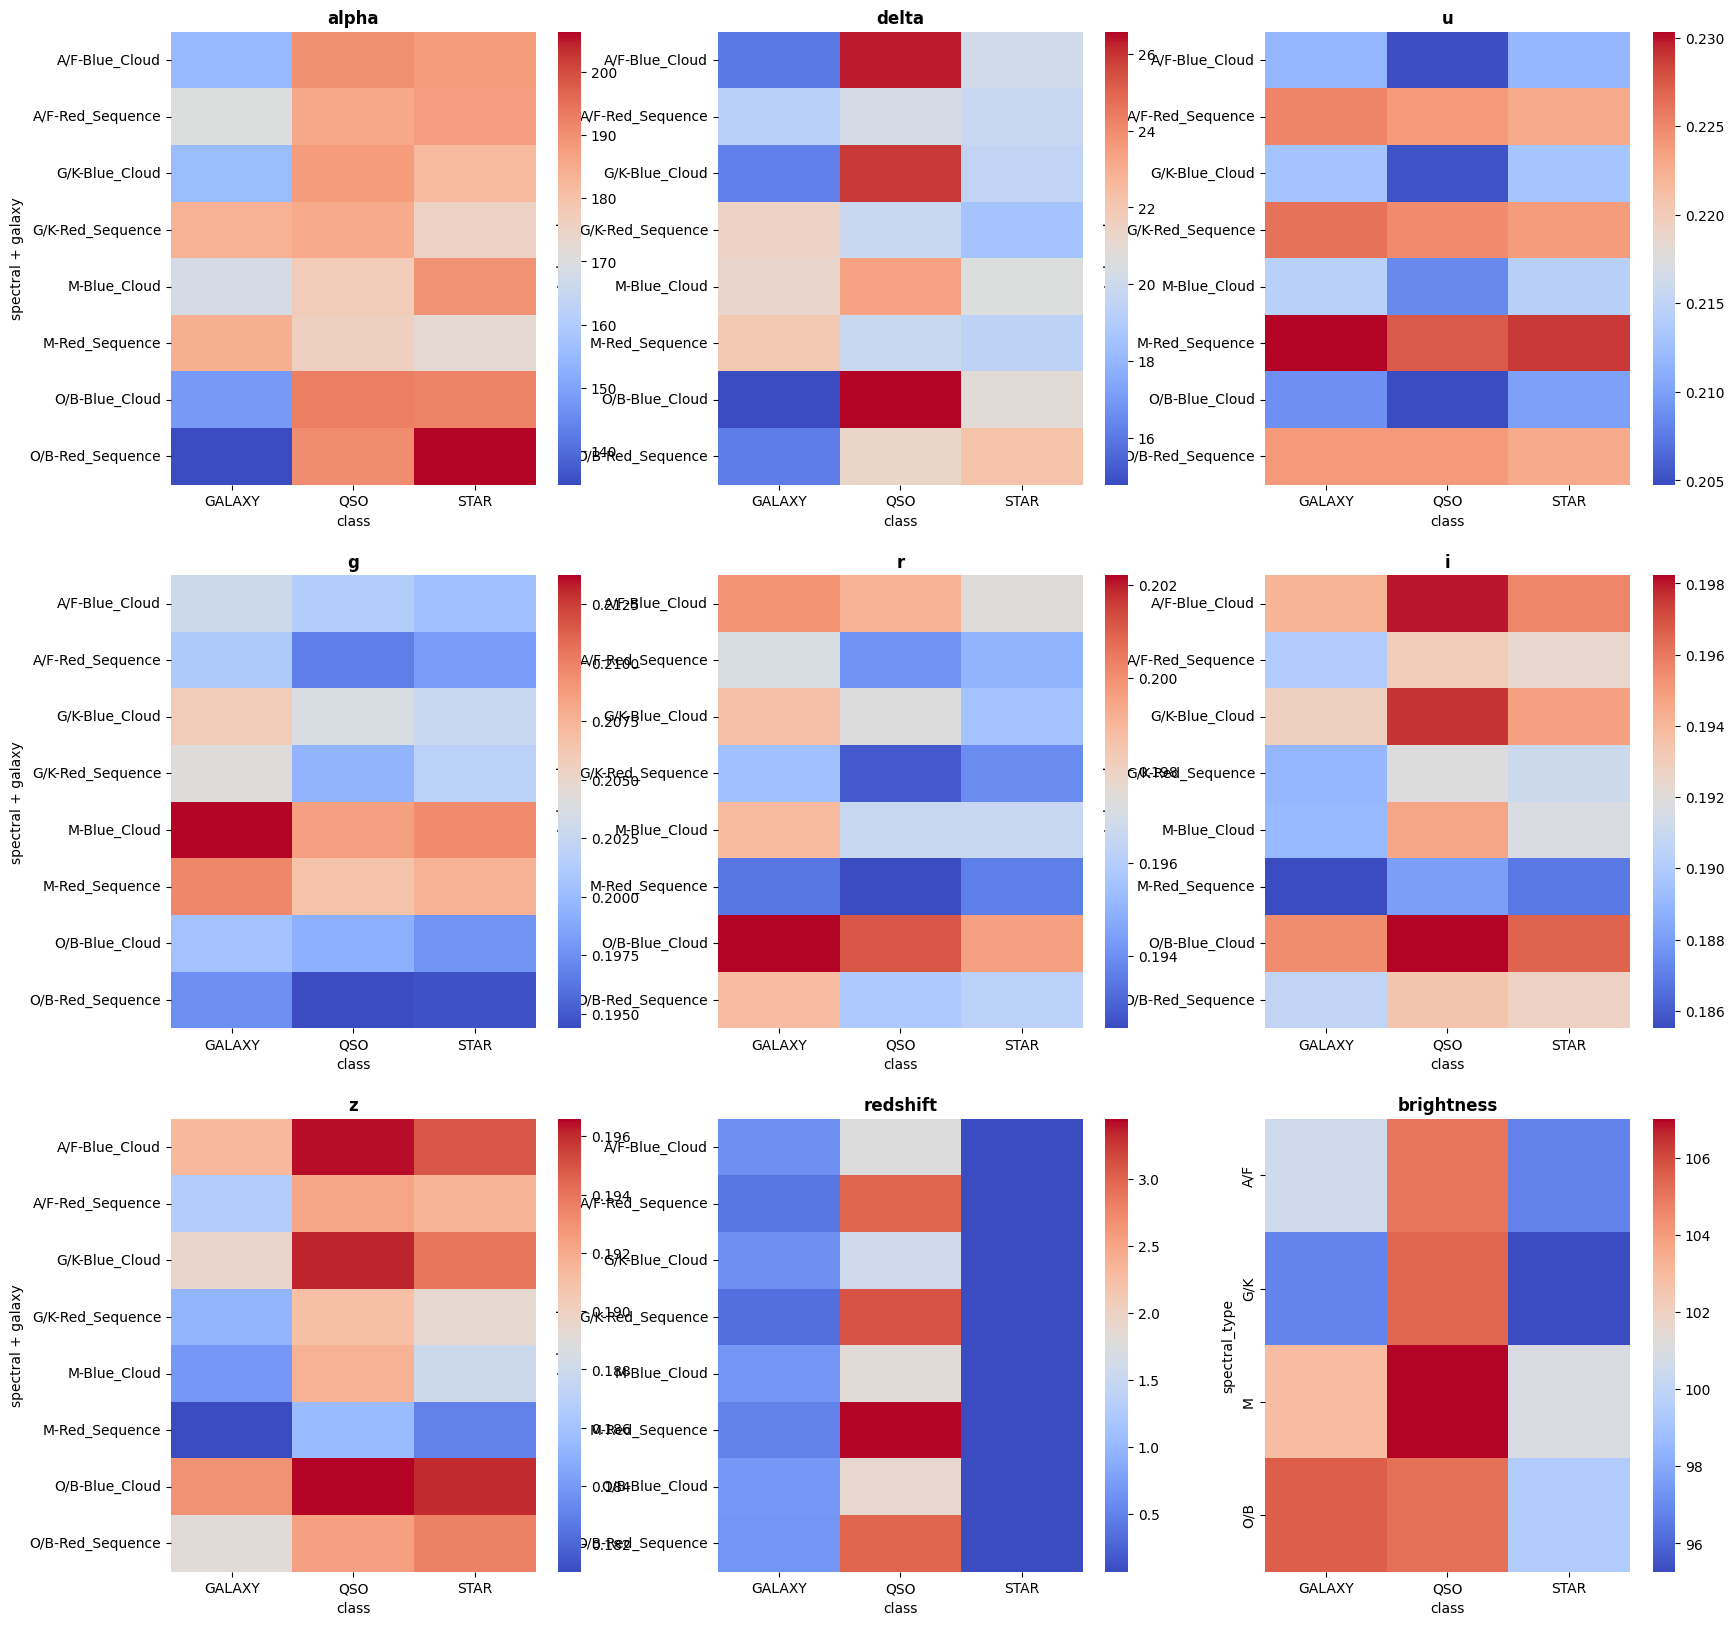

In [8]:
df_eda = df_train.copy()
df_eda['spectral + galaxy'] = df_eda['spectral_type'] + '-' + df_eda['galaxy_population']
eda(df_eda, 3, 3, [
    {'Plot' : 'pivot_heatmap' , 'values' : 'alpha' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'alpha'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'delta' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'delta'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'u_norm' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'u'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'g_norm' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'g'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'r_norm' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'r'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'i_norm' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'i'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'z_norm' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'z'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'redshift' , 'index' : 'spectral + galaxy', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'redshift'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'brightness' , 'index' : 'spectral_type', 'columns' : 'class', 'annot' : False, 'agg_function' : 'mean', 'title' : 'brightness'}
])

In [21]:
cat_cols = ['galaxy_population' , 'spectral_type']
if 'id' in df_train.columns:
    df_train.drop(columns='id', inplace=True)
X = df_train.drop(columns='class')
y = df_train['class'].copy()
scaler = StandardScaler()
X[X.columns.difference(cat_cols)] = scaler.fit_transform(X[X.columns.difference(cat_cols)])
X = pd.get_dummies(X)
le = LabelEncoder()
y = pd.DataFrame({'class' : le.fit_transform(y)})
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   alpha                           577347 non-null  float64
 1   delta                           577347 non-null  float64
 2   u                               577347 non-null  float64
 3   g                               577347 non-null  float64
 4   r                               577347 non-null  float64
 5   i                               577347 non-null  float64
 6   z                               577347 non-null  float64
 7   redshift                        577347 non-null  float64
 8   brightness                      577347 non-null  float64
 9   u_norm                          577347 non-null  float64
 10  g_norm                          577347 non-null  float64
 11  r_norm                          577347 non-null  float64
 12  i_norm                     

In [22]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   class   577347 non-null  int64
dtypes: int64(1)
memory usage: 4.4 MB


In [23]:
class NN_Multiclass_Model(BaseEstimator, ClassifierMixin):
    def __init__(self, geometry, l1, l2):
        self.geometry = geometry
        self.l1 = l1
        self.l2 = l2
        self.model = Sequential()
        self.model.add(Input(shape=(geometry[0],)))
        self.model.add(Dense(units=geometry[1], activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
        self.model.add(Dropout(0.3))
        self.model.add(Dense(units=geometry[2], activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
        self.model.add(Dropout(0.2))
        self.model.add(Dense(units=geometry[3], activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
        self.model.add(Dropout(0.2))
        self.model.add(Dense(units=geometry[4], activation="sigmoid"))
        self.model.compile(optimizer="adam" , loss="binary_crossentropy" , metrics=["accuracy"])
        self.ohe = OneHotEncoder(sparse_output=False)
    def fit(self, X, y):
        try:
            y = self.ohe.fit_transform(y.reshape(-1,1))
        except:
            y = self.ohe.fit_transform(y)
        self.model.fit(X, y , epochs=25 , batch_size = 32 , verbose = 1)
        return self
    def predict(self, X):
        return self.model.predict(X).argmax(axis=1)

In [ ]:
def get_models(nn_shape):
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42,
            solver='lbfgs'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_split=5,
            random_state=42, n_jobs=-1, class_weight='balanced'
        ),
        'XGBoost': XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, eval_metric='logloss', verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=100, max_depth=7, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, verbose=-1
        ),
        'KNN' : KNeighborsClassifier(n_neighbors=3),
        'AdaBoost' : AdaBoostClassifier(
            n_estimators=100, random_state=42, learning_rate=0.1
        ),
        'NN1' : NN_Multiclass_Model([nn_shape, 16, 12, 6, 3], 1e-4, 1e-3),
        'NN2' : NN_Multiclass_Model([nn_shape, 8, 6, 4, 3], 1e-4, 1e-3)
    }

In [ ]:
classifiers = get_models(X.shape[1])
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
ohe = OneHotEncoder(sparse_output=False)
y_tr_dummy = pd.get_dummies(y_tr)
y_val_dummy = ohe.fit_transform(y_val.to_numpy().reshape(-1,1)).astype(int)
for clf_name, clf in classifiers.items():
    if clf_name == 'NN1' or clf_name == 'NN2':
        clf.fit(X_tr, y_tr)
    else:
        clf.fit(X_tr, y_tr.values.ravel())
    y_pred = clf.predict(X_val)
    if hasattr(clf, 'predict_proba'):
        y_pred_proba = clf.predict_proba(X_val)
    elif hasattr(clf, 'decision_function'):
        y_pred_proba = clf.decision_function(X_val)
    else:
        y_pred_proba = None
    accuracy = accuracy_score(y_val, y_pred)
    y_pred_ohe = ohe.transform(y_pred.reshape(-1,1)).astype(int)
    f1 = f1_score(y_val_dummy, y_pred_ohe, zero_division=0, average=None)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_val_dummy, y_pred_proba,  multi_class='ovo')
    else:
        roc_auc = 0.0
    print(f'  {clf_name:20} | Acc: {accuracy:.4f} | F1: {f1} | ROC AUC: {roc_auc:.4f}')

W0000 00:00:1782328058.819094 1388045 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


  Logistic Regression  | Acc: 0.9133 | F1: [0.93866523 0.92371497 0.80521775] | ROC AUC: 0.9856
  Random Forest        | Acc: 0.9533 | F1: [0.96660374 0.95670868 0.89155722] | ROC AUC: 0.9933
  XGBoost              | Acc: 0.9626 | F1: [0.97391109 0.96233719 0.91105645] | ROC AUC: 0.9954
  LightGBM             | Acc: 0.9645 | F1: [0.97497487 0.96401309 0.91733657] | ROC AUC: 0.9957


In [ ]:
top_classifiers = ['Random Forest', 'XGBoost', 'LightGBM', 'NN1', 'NN2', 'Logistic Regression']
ensemble_dict = {}
classifiers = get_models(nn_shape = X.shape[1])
for name in top_classifiers:
    clf = classifiers[name]
    ensemble_dict[name] = clf
    print(f'✔ {name} trained')
ensemble = StackingClassifier(
    estimators=[(name, ensemble_dict[name]) for name in top_classifiers],
)
ensemble.fit(X, y)
ensemble_train_score = ensemble.score(X, y)
print(f'✔ Ensemble training accuracy: {ensemble_train_score:.4f}')

✔ Random Forest trained
✔ XGBoost trained
✔ LightGBM trained
✔ NN1 trained
✔ NN2 trained
✔ Logistic Regression trained


/home/kyburg/Code/Python/ML_env_312/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/kyburg/Code/Python/ML_env_312/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Epoch 1/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 82s 1ms/step - accuracy: 0.8902 - loss: 0.2161
Epoch 2/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - accuracy: 0.9067 - loss: 0.1956
Epoch 3/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 78s 1ms/step - accuracy: 0.9069 - loss: 0.1924
Epoch 4/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9073 - loss: 0.1905
Epoch 5/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.9081 - loss: 0.1893
Epoch 6/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 80s 1ms/step - accuracy: 0.9076 - loss: 0.1887
Epoch 7/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step - accuracy: 0.9090 - loss: 0.1880
Epoch 8/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.9090 - loss: 0.1883
Epoch 9/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.9095 - loss: 0.1871
Epoch 10/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step - accuracy: 0.9083 - loss: 0.1876
Epoch 11/25
72169/72169 ━━━━━━━━━━━━━━━━━━━━ 84s 1ms/step - accuracy: 0.9084 - loss: 0.18

In [ ]:
X_test = df_test.drop(columns='id')
scaler = StandardScaler()
X_test[X_test.columns.difference(cat_cols)] = scaler.fit_transform(X_test[X_test.columns.difference(cat_cols)])
X_test = pd.get_dummies(X_test)
y_pred_test = ensemble.predict(X_test)
y_pred_test = le.inverse_transform(y_pred_test)
submission = pd.DataFrame({
    'id' : df_test['id'],
    'Class' : y_pred_test
})
submission.to_csv('submission.csv', index=False)

7733/7733 ━━━━━━━━━━━━━━━━━━━━ 4s 451us/step
7733/7733 ━━━━━━━━━━━━━━━━━━━━ 3s 431us/step
